# Investigating data: ERA5 data from Weather Bench 2

In [110]:
import torch
import torch.nn
import torch.optim
from torch.utils.data import DataLoader

import xarray as xr
import numpy as np 

from constants import *

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy

In [111]:
device = torch.device("cuda")
dtype = torch.bfloat16

batch_size = 512
n_epochs = 20
n_layers = 4

In [112]:
ds = xr.open_zarr("/libre/finnt/data/teaching/wb2_train.zarr")
variable_names = [
    "geopotential", # geopotential at 500hPa
    "temperature", # temperature
    "humidity", # specific humidity, q at 700 level 
    "u_wind", # u_component_of_wind at 250 
    "v_wind", # v component of wind 
    "2m_temperature", # 2m temperature 
    "precipitation", # total precipitation in 6 hr 
]

ds = ds.assign_coords(var_name=variable_names)

In [113]:
ds

<xarray.Dataset> Size: 3GB
Dimensions:       (time: 56980, var_name: 7, longitude: 64, latitude: 32)
Coordinates:
  * time          (time) datetime64[ns] 456kB 1979-01-01 ... 2017-12-31T18:00:00
  * var_name      (var_name) <U14 392B 'geopotential' ... 'precipitation'
  * longitude     (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
  * latitude      (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
Data variables:
    geopotential  (time, var_name, longitude, latitude) float32 3GB ...

- ### 64 longitude and 32 latitude --> 5.6° resolution
- ### = 2048 points per time snapshot 
- ### 1 time point every 6 hours
- ### 7 variables: geopotential, temperature, specific humidity, u wind, v wind, 2m temperature, precipitation

Bisognerebbe cambiare anche le dimensioni delle altre variabili che sono tutte come il geopotenziale

In [114]:
ds["geopotential"].shape

(56980, 7, 64, 32)

In [115]:
ds["geopotential"].dims

('time', 'var_name', 'longitude', 'latitude')

In [116]:
ds["geopotential"].coords

Coordinates:
  * time       (time) datetime64[ns] 456kB 1979-01-01 ... 2017-12-31T18:00:00
  * var_name   (var_name) <U14 392B 'geopotential' ... 'precipitation'
  * longitude  (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
  * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19

In [117]:
dataset = ds["geopotential"] 
dataset.attrs

{'long_name': 'Geopotential',
 'short_name': 'z',
 'standard_name': 'geopotential',
 'units': 'm**2 s**-2'}

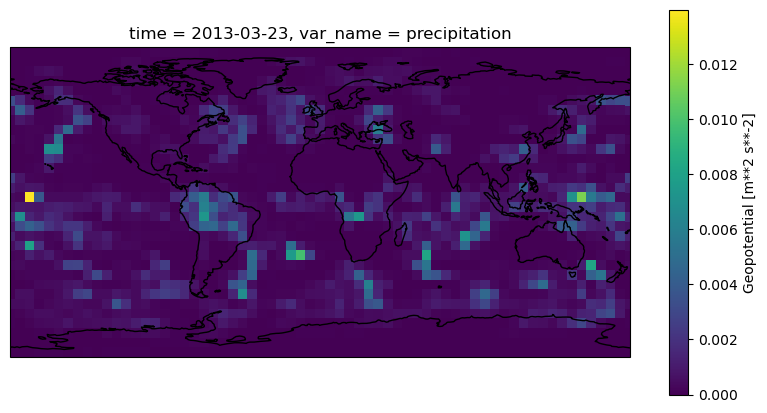

In [118]:
field = dataset.isel(time=50000, var_name=6)
field = field.transpose('latitude', 'longitude')
plt.figure(figsize=(10,5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
field.plot(ax=ax, transform=ccrs.PlateCarree())
plt.show()

In [119]:
#weights_lat = torch.as_tensor(weights_lat, device=device, dtype=dtype).squeeze()

In [120]:
#weights_lat # these are used to weigh the loss function 

In [121]:
dataset_compute = dataset.compute(num_workers=16) # actually imports the data, no lazy operations 
dataset_compute = dataset_compute.assign_coords(var_name=("var_name", variable_names))

variables = (torch.as_tensor(dataset_compute.values[:-1], dtype=dtype)-in_mean) / in_std # normalized variables 
residuals = (torch.as_tensor(dataset_compute.values[1:]-dataset_compute.values[:-1], dtype=dtype)-res_mean) / res_std # normalized residuals 

# del dataset_compute # remove useless stuff from RAM 

print(variables.shape) 
print(residuals.shape)

torch.Size([56979, 7, 64, 32])
torch.Size([56979, 7, 64, 32])


In [122]:
variables[0,0] # latitude and longitude matrix 

tensor([[-1.4851, -1.5790, -1.6728,  ..., -1.6728, -2.1419, -2.6110],
        [-1.4851, -1.5790, -1.6728,  ..., -1.7666, -2.2357, -2.6110],
        [-1.4851, -1.5790, -1.6728,  ..., -1.7666, -2.3295, -2.7048],
        ...,
        [-1.4851, -1.5790, -1.5790,  ..., -1.7666, -2.0481, -2.5172],
        [-1.4851, -1.5790, -1.5790,  ..., -1.6728, -2.0481, -2.5172],
        [-1.4851, -1.5790, -1.6728,  ..., -1.6728, -2.1419, -2.6110]])

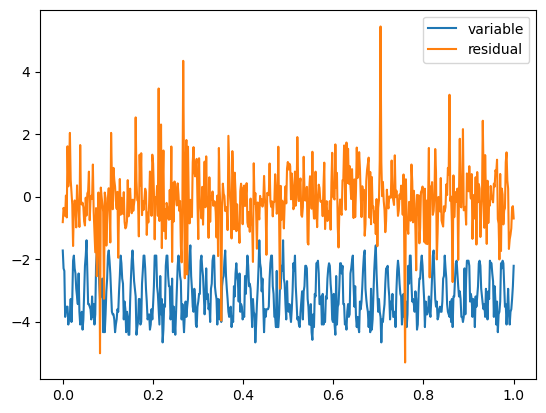

In [123]:
var_downsampled = variables[::100, 1, 0, 0]
res_donwsampled = residuals[::100, 1, 0, 0]
plt.plot(torch.linspace(0, 1, var_downsampled.shape[0]), var_downsampled, label="variable")
plt.plot(torch.linspace(0,1,res_donwsampled.shape[0]), res_donwsampled, label="residual")
plt.legend()
plt.show()

# Plot prediction

In [124]:
start_time = "1980-12-25 00:00"
end_time = "1984-01-10 00:00"

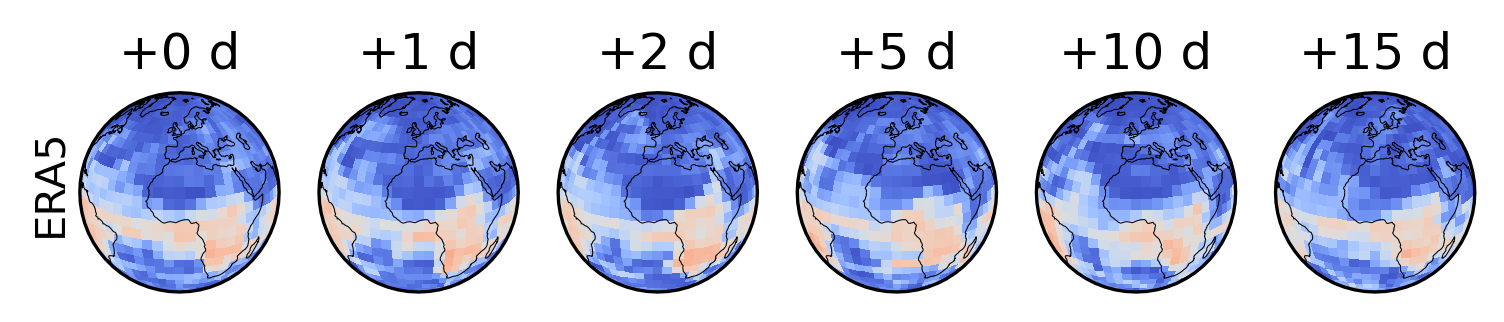

In [125]:
var_name = "humidity"
sliced_truth = dataset_compute.sel(
    time=slice(start_time, end_time),
    var_name=var_name
)
fig, ax = plt.subplots(
    ncols=6, nrows=1, figsize=(6, 1),
    subplot_kw={"projection": ccrs.NearsidePerspective(central_latitude=20)},
    dpi=300, # dimension of plots, resolution
    squeeze=False
)
vmin = float(sliced_truth.min())
vmax = float(sliced_truth.max())

for axi in ax:
    for axij in axi:
        axij.xaxis.set_visible(False)
        axij.yaxis.set_visible(False)
        axij.set_yticks([])
        axij.spines.left.set_visible(False)
        axij.spines.right.set_visible(False)
        axij.spines.bottom.set_visible(False)
        #axij.set_extent([-2_500_000, 2_000_000, -2_000_000, 2_500_000], ccrs.NorthPolarStereo())
        axij.add_feature(cartopy.feature.COASTLINE, zorder=98, lw=0.25)

ax[0,0].text(x=-0.25, y=.55, s="ERA5", rotation=90, transform=ax[0, 0].transAxes, ha="left", va="center")

for i, td in enumerate([0, 4, 8, 20, 40, 60]):
    img = sliced_truth.isel(time=td)
    ax[0,i].set_title("+{0:d} d".format(td//4))
    ax[0,i].pcolormesh(
        dataset_compute["longitude"], dataset_compute["latitude"],  img.T,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="coolwarm", 
        vmin=vmin, vmax=vmax
    )

# Power Spectrum

In [126]:
t = 0
var_name = "geopotential"
slice_t = dataset_compute.sel(
    time=slice(start_time, end_time),
    var_name=var_name
)
image = slice_t.isel(time=t)
Nx, Ny = image.shape
print(Nx,Ny)
fourier_t = np.fft.fft2(image)
power_spectrum = np.abs(fourier_t)**2 
power_shifted = np.fft.fftshift(power_spectrum) 

kx = np.fft.fftfreq(Nx) * Nx 
print(np.max(kx)) 
ky = np.fft.fftfreq(Ny) * Ny
print(np.max(ky))

kx_shift = np.fft.fftshift(kx)
ky_shift = np.fft.fftshift(ky)

64 32
31.0
15.0


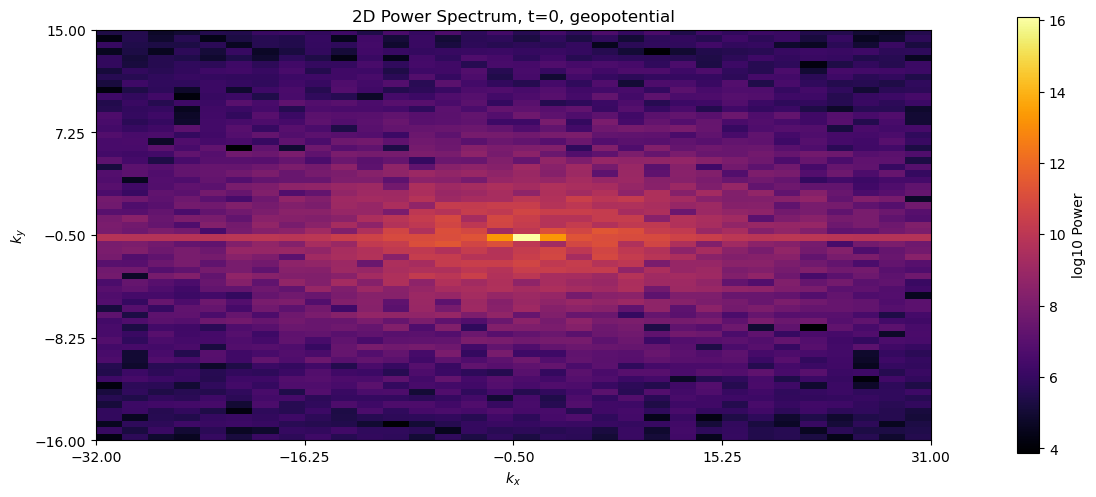

In [127]:
plt.figure(figsize=(12, 5))
clipped = np.clip(power_shifted, 0, np.percentile(power_shifted, 99))

plt.imshow(
    np.log10(power_shifted + 1),
    cmap='inferno',
    extent=[kx_shift[0], kx_shift[-1], ky_shift[0], ky_shift[-1]]
)
cbar = plt.colorbar(pad=0.08)
cbar.set_label('log10 Power')
plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title(f"2D Power Spectrum, t={t}, {var_name}")
nx_ticks = 5
ny_ticks = 5
plt.xticks(np.linspace(kx_shift[0], kx_shift[-1], nx_ticks))
plt.yticks(np.linspace(ky_shift[0], ky_shift[-1], ny_ticks))
plt.tight_layout()
plt.show()

# 1D Power Spectrum: rectangle radial average

In [128]:
KX, KY = np.meshgrid(kx, ky) 
knrm = np.sqrt(KX**2 + KY**2) # k**2 = kx**2 + ky**2 

# |k| flattened 
knrm = knrm.flatten()
print(power_spectrum.shape)
amps = power_spectrum.flatten()

kmax = min(Nx, Ny) // 2 # max frequency up to minimum Nyquist 
kbins = np.arange(0.5, kmax + 1, 1.0)
kvals = 0.5 * (kbins[1:] + kbins[:-1])

from scipy.stats import binned_statistic

Abins, _, _ = binned_statistic(
    knrm, amps,
    statistic="mean",
    bins=kbins
)

(64, 32)


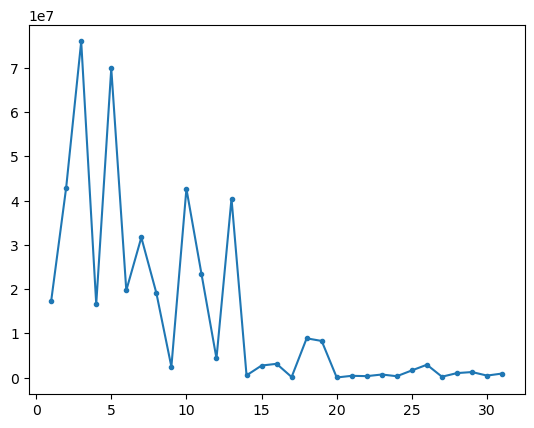

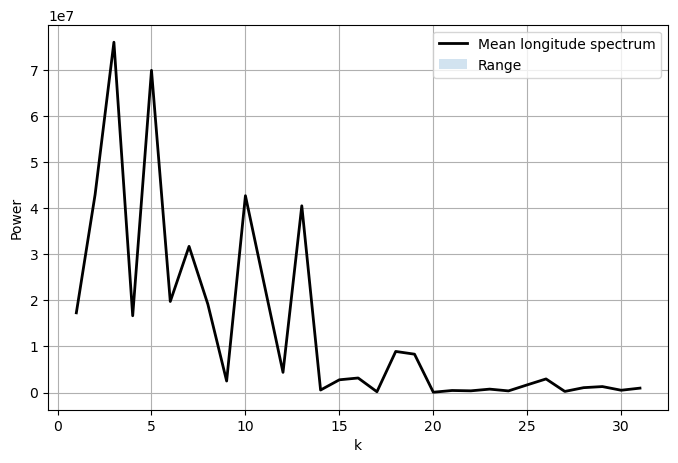

In [129]:
# taking a horizontal slice 
def spectrum_fixed_lat(lat):
    amps_x = power_spectrum[:,lat]
    knrm_x = np.copy(kx) 
    kbins_x = np.arange(0.5, Nx + 1, 1.0)
    kvals_x = 0.5 * (kbins_x[1:] + kbins_x[:-1])
    Abins_x, _, _ = binned_statistic(
        knrm_x, amps_x,
        statistic="mean",
        bins= kbins_x
    )
    plt.plot(kvals_x, Abins_x, "o-", markersize=3)

    return Abins_x, kvals_x

all_spectra = [] 
for lat in range(20,21): 
    Abins_x, kvals_x = spectrum_fixed_lat(lat)
    all_spectra.append(Abins_x)

plt.show()

# compute average and range of spectra 
mean_spec = np.mean(all_spectra, axis=0)
std_spec  = np.std(all_spectra, axis=0)
min_spec  = np.min(all_spectra, axis=0)
max_spec  = np.max(all_spectra, axis=0)
plt.figure(figsize=(8,5))

plt.plot(kvals_x, mean_spec, "k-", lw=2, label="Mean longitude spectrum")

# envelope shading
plt.fill_between(kvals_x, min_spec, max_spec, alpha=0.2, label="Range")
# or: plt.fill_between(kvals_x, mean_spec-std_spec, mean_spec+std_spec, alpha=0.2)

plt.xlabel("k")
plt.ylabel("Power")
plt.legend()
plt.grid(True)
plt.show()

# Fixed longitude spectrum 

10 8
(32,)
bins (9,)
(8,)
(8,)


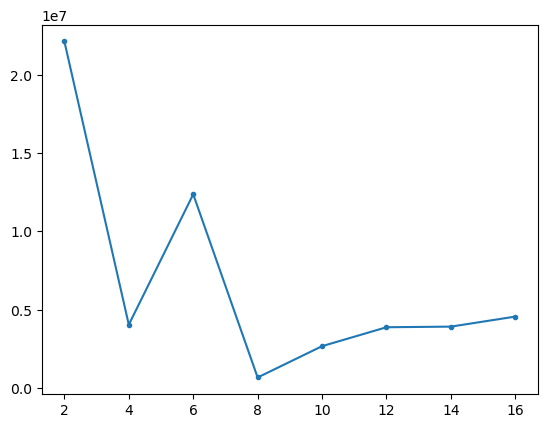

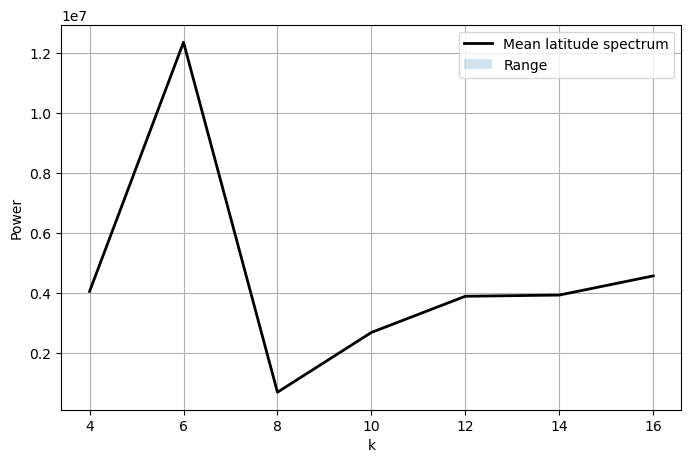

In [106]:
# taking a vertical slice 
print(Nx, Ny)
def spectrum_fixed_long(long):
    amps_y = power_spectrum[long,:]
    knrm_y = ky
    print(ky.shape) # 32 
    kbins_y = np.arange(0.5, Ny + 1, 1.0)
    print("bins", kbins_y.shape)
    kvals_y = (kbins_y[1:] + kbins_y[:-1])
    print(kvals_y.shape)
    Abins_y, _, _ = binned_statistic(
        knrm_y, amps_y,
        statistic="mean",
        bins= kbins_y
    )
    print(kvals_y.shape)
    plt.plot(kvals_y, Abins_y, "o-", markersize=3)

    return Abins_y, kvals_y

all_spectra = [] 
for long in range(20,21): 
    Abins_y, kvals_y = spectrum_fixed_long(long)
    all_spectra.append(Abins_y)

plt.show()

# compute average and range of spectra 
mean_spec = np.mean(all_spectra, axis=0)
std_spec  = np.std(all_spectra, axis=0)
min_spec  = np.min(all_spectra, axis=0)
max_spec  = np.max(all_spectra, axis=0)
plt.figure(figsize=(8,5))

plt.plot(kvals_y[1:], mean_spec[1:], "k-", lw=2, label="Mean latitude spectrum")

# envelope shading
plt.fill_between(kvals_y[1:], min_spec[1:], max_spec[1:], alpha=0.2, label="Range")
# or: plt.fill_between(kvals_x, mean_spec-std_spec, mean_spec+std_spec, alpha=0.2)

plt.xlabel("k")
plt.ylabel("Power")
plt.legend()
plt.grid(True)
#plt.show()

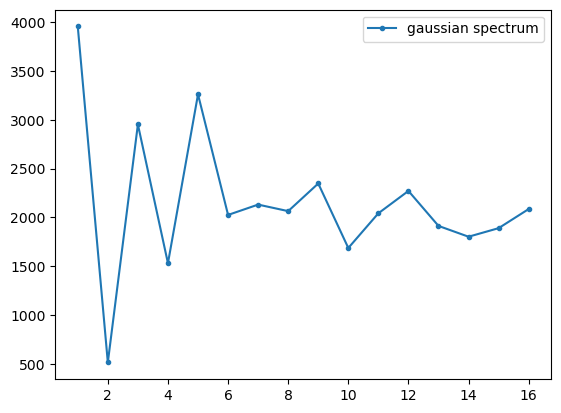

In [86]:
# 1D power spectrum of gaussian field for comparison 
gaussian_field = np.random.normal(loc=0.0, scale=1.0, size=(Ny,Nx)) # (32, 64)
fft_gaussian = np.fft.fft2(gaussian_field) 
power_gaussian = np.abs(fft_gaussian)**2 
amps_gaussian = power_gaussian.flatten()
Abins_gaussian, _, _ = binned_statistic(
    knrm, amps_gaussian,
    statistic="mean", 
    bins=kbins
)  

plt.plot(kvals, Abins_gaussian, "o-", markersize=3, label="gaussian spectrum")
#plt.plot(kvals[1:], Abins[1:], "o-", markersize=3, label="val")
plt.legend()
plt.show()

off-diag mean after DFT diagonalization: 1.7586033164997085e-14


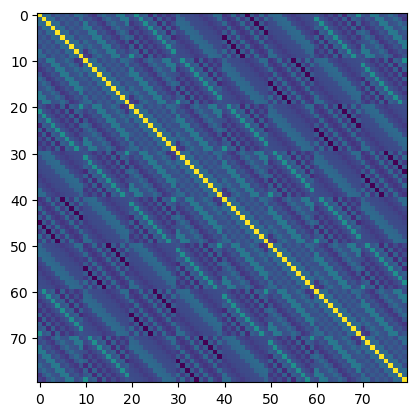

In [87]:
# build full covariance matrix (small sizes only!)
Ny, Nx = 8, 10
X = np.random.normal(size=(Ny, Nx))

# empirical autocovariance from a single realization (as above)
F = np.fft.fft2(X)
PSD = np.abs(F)**2
auto = np.fft.ifft2(PSD).real  # Ny x Nx, lag-space (with periodic BC)

# make a function that maps a flattened vector v -> convolution with auto
from scipy.linalg import circulant  # not directly usable for 2D, below show brute force

def convolution_matrix_from_autocov(auto):
    Ny, Nx = auto.shape
    N = Ny * Nx
    C = np.zeros((N, N))
    # create mapping from linear index to (iy,ix)
    coords = [(iy, ix) for iy in range(Ny) for ix in range(Nx)]
    for a, (iy, ix) in enumerate(coords):
        # covariance between pixel (iy,ix) and all pixels (jy,jx) equals auto at lag (jy-iy, jx-ix) modulo dims
        for b, (jy, jx) in enumerate(coords):
            dy = (jy - iy) % Ny
            dx = (jx - ix) % Nx
            C[a, b] = auto[dy, dx]
    return C

# warning: size grows as N^2; only use small Ny,Nx
C_full = convolution_matrix_from_autocov(auto)
# now C_full should be diagonalized by DFT:
# compute FFT matrix U implicitly by applying DFT to basis vectors is expensive; instead verify:
# transform C_full into Fourier basis by reshaping and fft2 on matrix columns:
N = Ny*Nx
# build matrix of Fourier vectors for basis conversion (explicit)
U = np.zeros((N, N), dtype=complex)
for j in range(N):
    vec = np.zeros((Ny, Nx), dtype=complex)
    vec.flat[j] = 1.0
    U[:, j] = np.fft.fft2(vec).reshape(-1)

# check diagonalization: U^{-1} C_full U should be approximately diagonal
eig_like = np.linalg.inv(U) @ C_full @ U
offdiag_mean = np.mean(np.abs(eig_like - np.diag(np.diag(eig_like))))
print("off-diag mean after DFT diagonalization:", offdiag_mean)

plt.imshow(C_full)


In [66]:
from scipy.interpolate import UnivariateSpline
import powerbox as pbox
pk_interp = UnivariateSpline(np.log10(kvals), np.log10(Abins))  # interpolate the P(k) in loglog
# Generate 
lnpb = pbox.PowerBox(
    N=Ny,                    # Number of grid-points in the box
    dim=2,                     # 2D box
    pk = lambda k: 10**pk_interp(np.log10(k)),      # The power-spectrum
    boxlength = 1.0,           # Size of the box (sets the units of k in pk)
    seed = 1010                
)


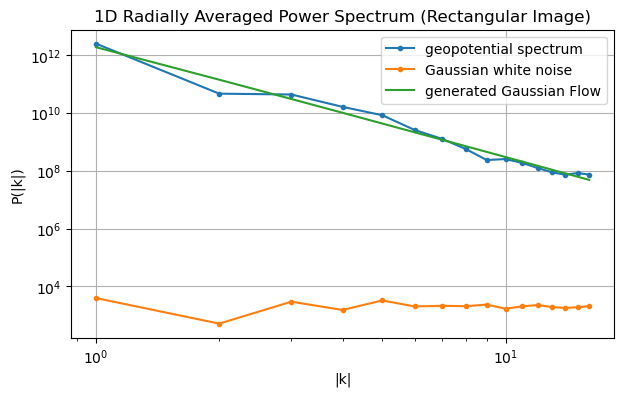

In [88]:
plt.figure(figsize=(7,4))
plt.loglog(kvals, Abins, 'o-', markersize=3, label=f"{var_name} spectrum")
plt.loglog(kvals, Abins_gaussian, "o-", markersize=3, label="Gaussian white noise")
plt.loglog(kvals,10**pk_interp(np.log10(kvals)), label='generated Gaussian Flow')

plt.xlabel("|k|")
plt.ylabel("P(|k|)")
plt.title("1D Radially Averaged Power Spectrum (Rectangular Image)")
plt.legend()
plt.grid(True)
plt.show()